# 03 - Exploratory Data Analysis and Business Insights

This notebook performs exploratory data analysis on the Amsterdam Inside Airbnb market using the cleaned DuckDB warehouse outputs.

The goal is to identify market patterns related to listing supply, room types, pricing, availability, occupancy proxy, host behavior, neighbourhood performance, review scores, and business opportunities.

Each finding includes a business interpretation to make the analysis useful for non-technical stakeholders.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path("..")

WAREHOUSE_PATH = PROJECT_ROOT / "warehouse"
DUCKDB_DATABASE_PATH = WAREHOUSE_PATH / "airbnb_market.duckdb"

FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("DuckDB database exists:", DUCKDB_DATABASE_PATH.exists())
print("Figures path:", FIGURES_PATH)

DuckDB database exists: True
Figures path: ..\reports\figures


In [6]:
conn = duckdb.connect(database=str(DUCKDB_DATABASE_PATH))

print("Connected to DuckDB successfully.")

Connected to DuckDB successfully.


In [7]:
conn.execute("""
SHOW TABLES
""").fetchdf()

,name
0,dim_host
1,dim_listing
2,dim_neighbourhood
3,fact_listing_market
4,host_portfolio_summary
5,listing_master_final
6,market_overview
7,neighbourhood_summary
8,review_score_summary
9,room_type_summary


In [8]:
market_overview_df = conn.execute("SELECT * FROM market_overview").fetchdf()
room_type_summary_df = conn.execute("SELECT * FROM room_type_summary").fetchdf()
neighbourhood_summary_df = conn.execute("SELECT * FROM neighbourhood_summary").fetchdf()
host_portfolio_summary_df = conn.execute("SELECT * FROM host_portfolio_summary").fetchdf()
review_score_summary_df = conn.execute("SELECT * FROM review_score_summary").fetchdf()

listing_master_df = conn.execute("SELECT * FROM listing_master_final").fetchdf()

print("market_overview:", market_overview_df.shape)
print("room_type_summary:", room_type_summary_df.shape)
print("neighbourhood_summary:", neighbourhood_summary_df.shape)
print("host_portfolio_summary:", host_portfolio_summary_df.shape)
print("review_score_summary:", review_score_summary_df.shape)
print("listing_master_final:", listing_master_df.shape)

market_overview: (1, 14)
room_type_summary: (4, 12)
neighbourhood_summary: (22, 13)
host_portfolio_summary: (5, 11)
review_score_summary: (5, 10)
listing_master_final: (10465, 101)


## 1. Market Overview

This section summarizes the overall Amsterdam Airbnb market using listing counts, host counts, neighbourhood coverage, pricing, availability, review activity, and revenue proxy metrics.

In [9]:
market_overview_df.T

,0
total_listings,1.046500e+04
total_known_hosts,9.104000e+03
total_neighbourhoods,2.200000e+01
avg_listing_price,3.442400e+02
median_listing_price,2.870000e+02
avg_availability_rate,2.615000e-01
avg_occupancy_proxy,7.385000e-01
listings_with_reviews,9.432000e+03
listings_without_reviews,1.033000e+03
total_detailed_reviews,5.451620e+05


### Business Interpretation

The Amsterdam Airbnb dataset contains 10,465 listings across 22 neighbourhoods.  
The market has strong review coverage, with most listings having at least one review.

The average occupancy proxy is higher than the average availability rate, suggesting that many listings are unavailable for a large portion of the calendar year.  
However, this should be interpreted carefully because unavailable dates may include both booked nights and host-blocked dates.

The revenue proxy is useful for comparing segments but should not be treated as actual revenue because the calendar dataset does not include daily price fields.

## 2. Room Type Analysis

This section compares Airbnb listing supply, pricing, availability, occupancy proxy, review scores, and revenue proxy by room type.

In [10]:
room_type_summary_df

,room_type,listing_count,market_share_percentage,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,Entire home/apt,8489,81.12,394.62,331.0,0.2133,0.7867,4.87,221489.0,407899491.0,85495.60,3718.0
1,Private room,1929,18.43,203.67,171.0,0.4612,0.5388,4.77,311510.0,55409327.0,33520.46,276.0
2,Hotel room,26,0.25,249.85,227.5,0.7564,0.2436,4.78,6169.0,623504.0,23980.92,0.0
3,Shared room,21,0.20,80.10,52.0,0.7769,0.2231,4.52,5994.0,242392.0,11542.48,0.0


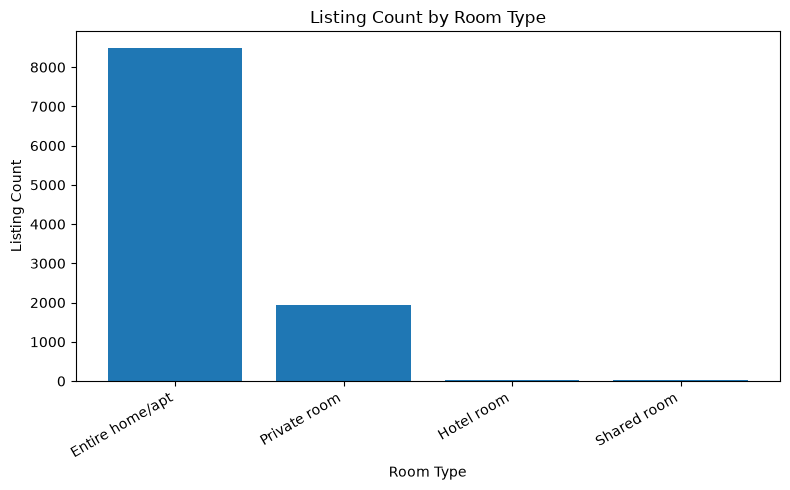

Saved figure to: ..\reports\figures\listing_count_by_room_type.png


In [11]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["listing_count"])
plt.title("Listing Count by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Listing Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "listing_count_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

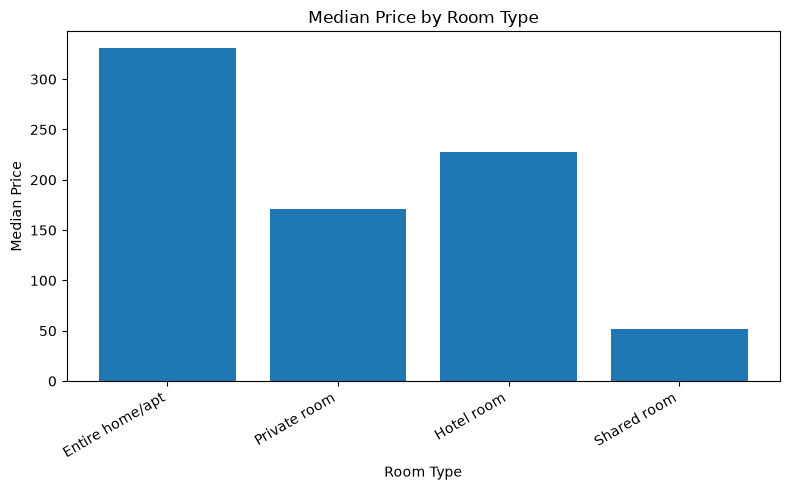

Saved figure to: ..\reports\figures\median_price_by_room_type.png


In [12]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["median_price"])
plt.title("Median Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Median Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "median_price_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

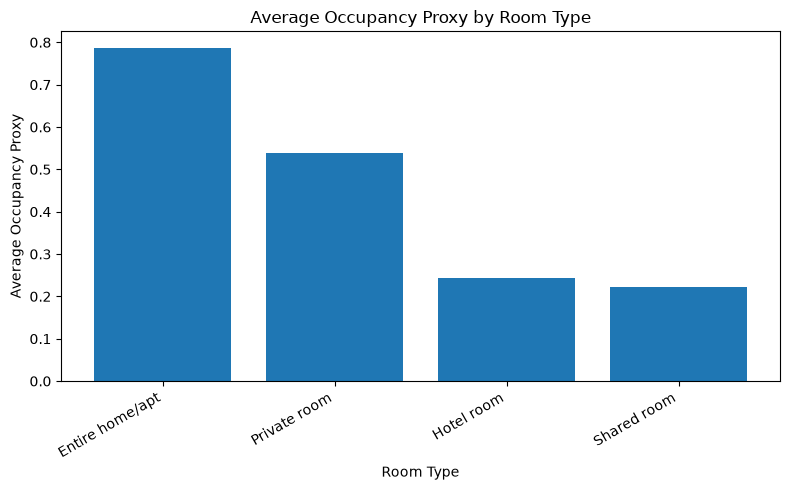

Saved figure to: ..\reports\figures\occupancy_proxy_by_room_type.png


In [13]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["avg_occupancy_proxy"])
plt.title("Average Occupancy Proxy by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Occupancy Proxy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Entire home/apartment listings dominate the Amsterdam Airbnb market by listing count and market share.  
They also show higher median pricing and a stronger occupancy proxy compared with private rooms.

This suggests that entire-home listings are the core commercial segment of the Amsterdam short-term rental market.  
Private rooms appear to be a lower-priced segment with higher availability, which may indicate weaker demand or different host usage patterns.

Hotel rooms and shared rooms have very small listing counts, so their metrics should be interpreted cautiously.

## 3. Neighbourhood Analysis

This section analyzes Airbnb market patterns across Amsterdam neighbourhoods.

The analysis focuses on listing supply, median price, occupancy proxy, review scores, and estimated revenue proxy by neighbourhood.

In [14]:
neighbourhood_summary_df.head(10)

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0


In [15]:
top_neighbourhoods_by_supply = (
    neighbourhood_summary_df
    .sort_values("listing_count", ascending=False)
    .head(10)
)

top_neighbourhoods_by_supply

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0


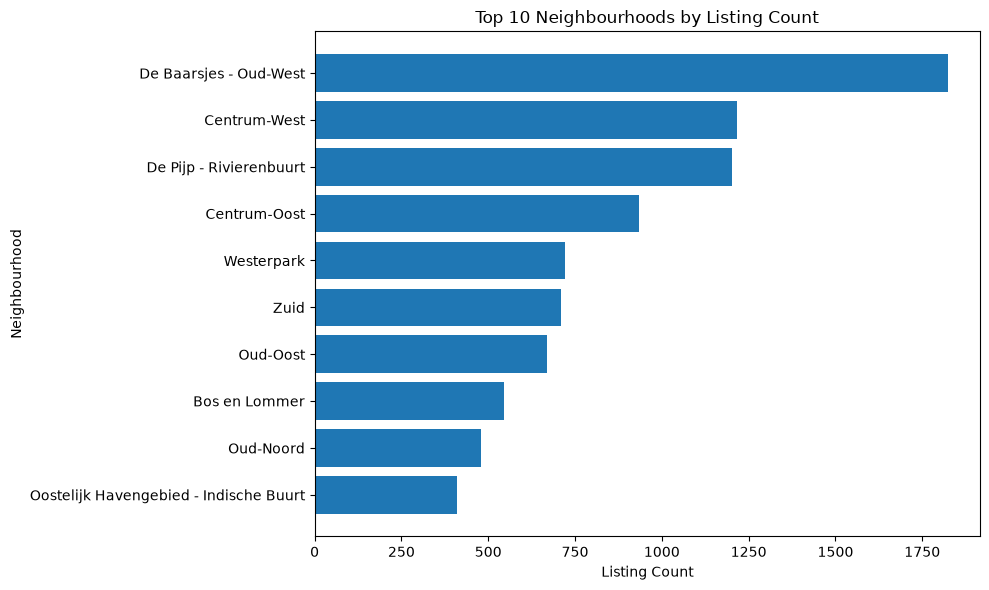

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_listing_count.png


In [16]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_supply["neighbourhood"],
    top_neighbourhoods_by_supply["listing_count"]
)
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.xlabel("Listing Count")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_listing_count.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

A small number of neighbourhoods account for a large share of Airbnb supply in Amsterdam.  
High-supply neighbourhoods may represent mature short-term rental zones with strong tourism demand, high host participation, or attractive location characteristics.

For platform operators and market analysts, these areas should be monitored closely because changes in regulation, demand, or host behavior could have a large impact on the overall market.

In [17]:
top_neighbourhoods_by_price = (
    neighbourhood_summary_df
    .dropna(subset=["median_price"])
    .sort_values("median_price", ascending=False)
    .head(10)
)

top_neighbourhoods_by_price

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
12,IJburg - Zeeburgereiland,187,174,330.72,287.0,0.2342,0.7658,4.85,8494.0,45.42,8675081.0,74785.18,71.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
11,Watergraafsmeer,304,272,311.24,280.0,0.2552,0.7448,4.86,10560.0,34.74,13291645.0,71460.46,118.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
13,Noord-Oost,179,154,288.65,266.5,0.2646,0.7354,4.87,7073.0,39.51,8353883.0,67370.02,55.0


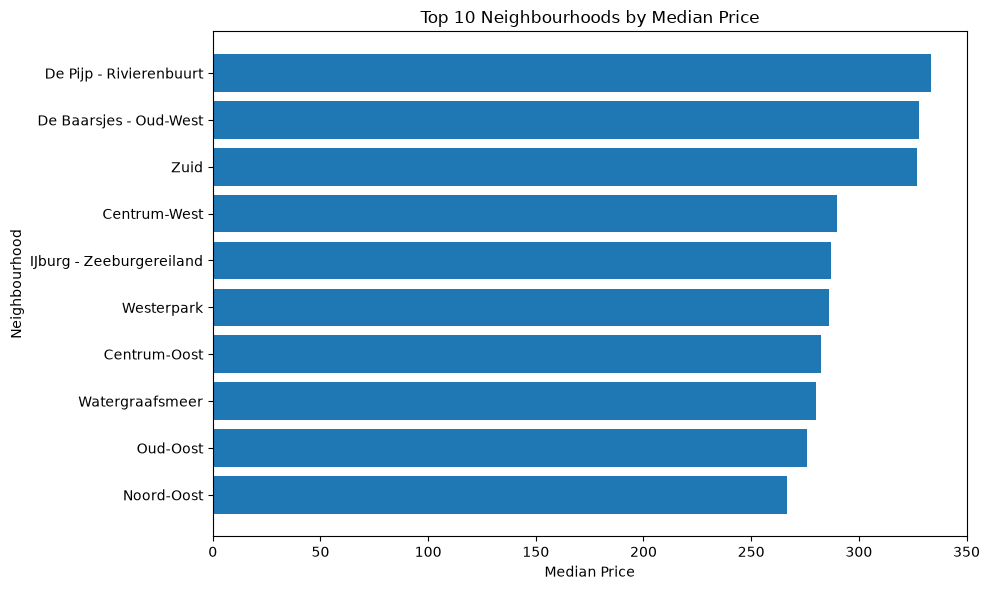

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_median_price.png


In [18]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_price["neighbourhood"],
    top_neighbourhoods_by_price["median_price"]
)
plt.title("Top 10 Neighbourhoods by Median Price")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_median_price.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Neighbourhoods with higher median prices may represent premium locations, stronger tourism appeal, better accessibility, or more desirable property types.

Price differences across neighbourhoods can help hosts benchmark pricing strategies and help investors identify high-value market areas.  
However, pricing should be interpreted together with occupancy proxy, review scores, and listing count because high price alone does not always indicate strong performance.

In [19]:
top_neighbourhoods_by_occupancy = (
    neighbourhood_summary_df
    .sort_values("avg_occupancy_proxy", ascending=False)
    .head(10)
)

top_neighbourhoods_by_occupancy

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
10,Noord-West,312,292,265.23,259.0,0.2008,0.7992,4.87,10339.0,33.14,14127902.0,68916.60,107.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
21,Bijlmer-Oost,39,33,206.67,120.5,0.2225,0.7775,4.79,1646.0,42.21,1153954.0,48081.42,15.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
14,Slotervaart,223,196,253.38,233.0,0.2283,0.7717,4.87,10228.0,45.87,6851824.0,56626.64,102.0
12,IJburg - Zeeburgereiland,187,174,330.72,287.0,0.2342,0.7658,4.85,8494.0,45.42,8675081.0,74785.18,71.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0


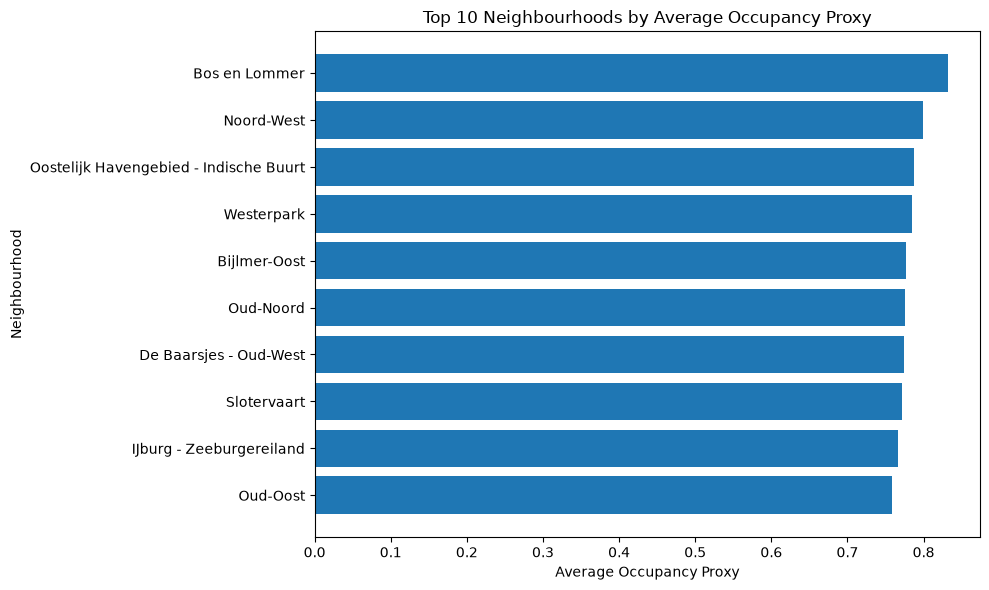

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_occupancy_proxy.png


In [20]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_occupancy["neighbourhood"],
    top_neighbourhoods_by_occupancy["avg_occupancy_proxy"]
)
plt.title("Top 10 Neighbourhoods by Average Occupancy Proxy")
plt.xlabel("Average Occupancy Proxy")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_occupancy_proxy.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Neighbourhoods with higher occupancy proxy have lower availability across the calendar year.  
This may indicate stronger demand, more frequent bookings, or hosts blocking dates for reasons outside guest demand.

Because unavailable dates are not confirmed bookings, this metric should be interpreted as a demand proxy rather than actual occupancy.

In [21]:
top_neighbourhoods_by_revenue_proxy = (
    neighbourhood_summary_df
    .sort_values("total_revenue_proxy", ascending=False)
    .head(10)
)

top_neighbourhoods_by_revenue_proxy

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0


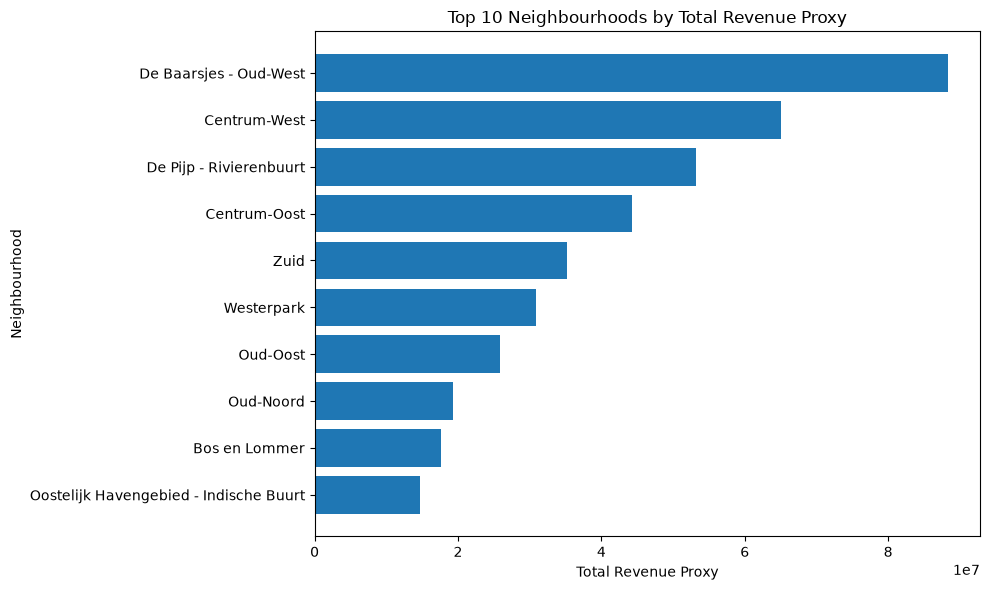

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_revenue_proxy.png


In [22]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_revenue_proxy["neighbourhood"],
    top_neighbourhoods_by_revenue_proxy["total_revenue_proxy"]
)
plt.title("Top 10 Neighbourhoods by Total Revenue Proxy")
plt.xlabel("Total Revenue Proxy")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_revenue_proxy.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Neighbourhoods with high total revenue proxy usually combine three factors: high listing supply, higher prices, and strong occupancy proxy.

This metric is useful for comparing relative market strength across neighbourhoods, but it should not be treated as actual revenue because it is estimated using listing-level price and unavailable calendar days.

## 4. Host Portfolio Analysis

This section analyzes Airbnb listings by host portfolio segment.

Host portfolio segmentation helps identify whether the market is mostly driven by single-listing hosts, small portfolio hosts, or larger professional-style operators.

In [23]:
host_portfolio_summary_df

,host_portfolio_segment,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy
0,Single-listing host,8509,8509,371.11,318.0,0.2085,0.7915,4.88,334320.0,396232619.0,82359.72
1,Small portfolio host,1309,537,274.87,202.0,0.4396,0.5604,4.76,161660.0,47775711.0,45113.99
2,Medium portfolio host,483,55,276.40,209.0,0.5640,0.4360,4.65,34771.0,17365435.0,39377.40
3,Unknown Host,96,0,177.53,141.0,0.7595,0.2405,NaN,9048.0,1314652.0,13985.66
4,Large portfolio host,68,3,189.39,151.0,0.6113,0.3887,4.54,5363.0,1486297.0,22519.65


In [24]:
host_portfolio_chart_df = (
    host_portfolio_summary_df
    .sort_values("listing_count", ascending=False)
    .copy()
)

host_portfolio_chart_df

,host_portfolio_segment,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy
0,Single-listing host,8509,8509,371.11,318.0,0.2085,0.7915,4.88,334320.0,396232619.0,82359.72
1,Small portfolio host,1309,537,274.87,202.0,0.4396,0.5604,4.76,161660.0,47775711.0,45113.99
2,Medium portfolio host,483,55,276.40,209.0,0.5640,0.4360,4.65,34771.0,17365435.0,39377.40
3,Unknown Host,96,0,177.53,141.0,0.7595,0.2405,NaN,9048.0,1314652.0,13985.66
4,Large portfolio host,68,3,189.39,151.0,0.6113,0.3887,4.54,5363.0,1486297.0,22519.65


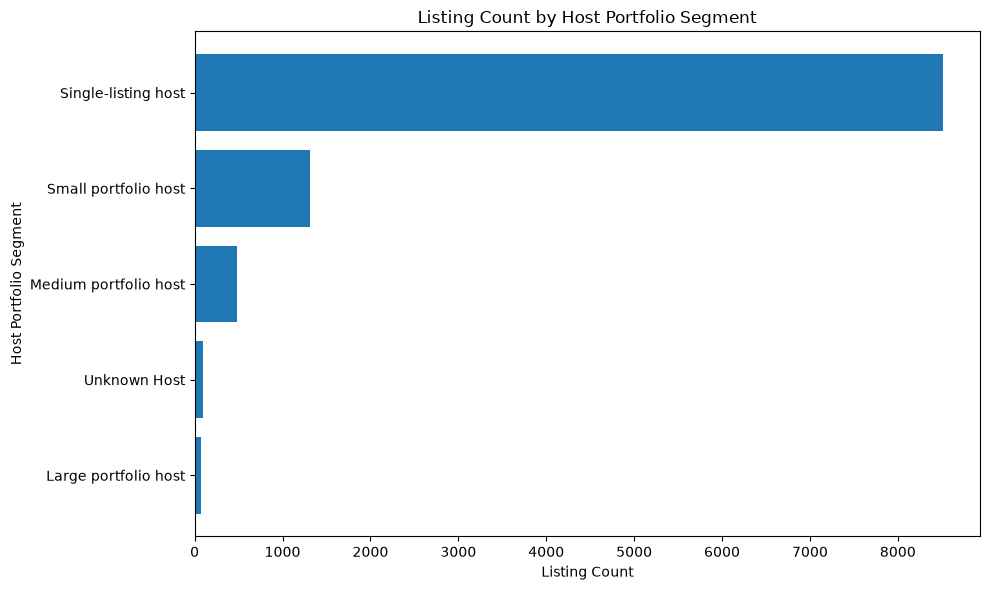

Saved figure to: ..\reports\figures\listing_count_by_host_portfolio_segment.png


In [25]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["listing_count"]
)
plt.title("Listing Count by Host Portfolio Segment")
plt.xlabel("Listing Count")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "listing_count_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Single-listing hosts account for the largest share of Airbnb listings in the Amsterdam dataset.  
This suggests that the market is strongly driven by individual or casual hosts rather than only large professional operators.

However, small and medium portfolio hosts still represent an important commercial segment because they manage multiple listings and may use more structured pricing and availability strategies.

The Unknown Host segment represents records with missing host information and should be treated as a data quality category rather than a real host segment.

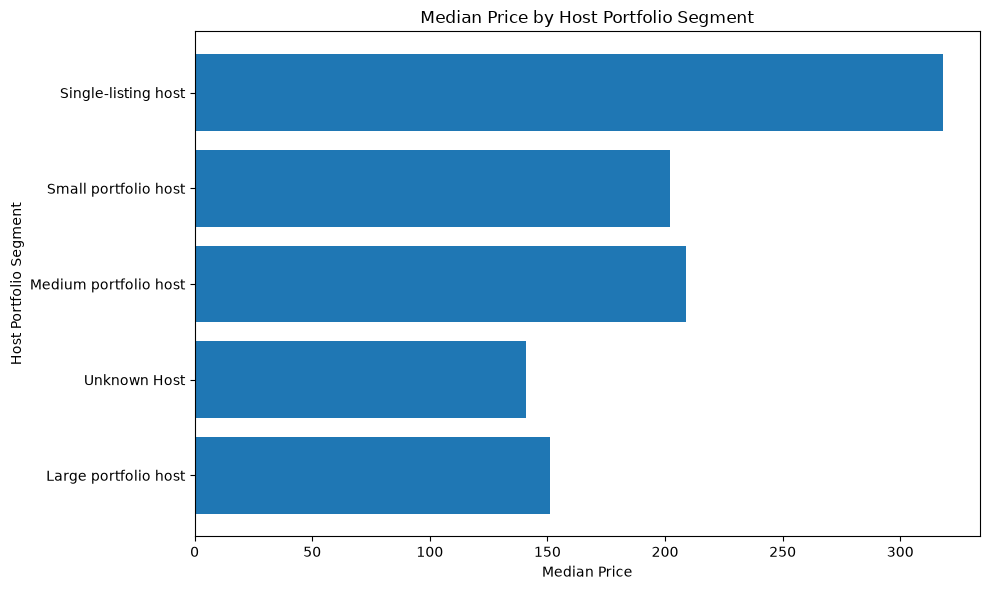

Saved figure to: ..\reports\figures\median_price_by_host_portfolio_segment.png


In [26]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["median_price"]
)
plt.title("Median Price by Host Portfolio Segment")
plt.xlabel("Median Price")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "median_price_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Median price varies across host portfolio segments.  
Single-listing hosts show higher median pricing than larger portfolio segments in this dataset.

This may indicate that single-listing hosts are offering more differentiated or premium homes, while larger portfolio operators may manage more standardized or lower-priced inventory.  
This should be investigated further with property type and neighbourhood context before making a final conclusion.

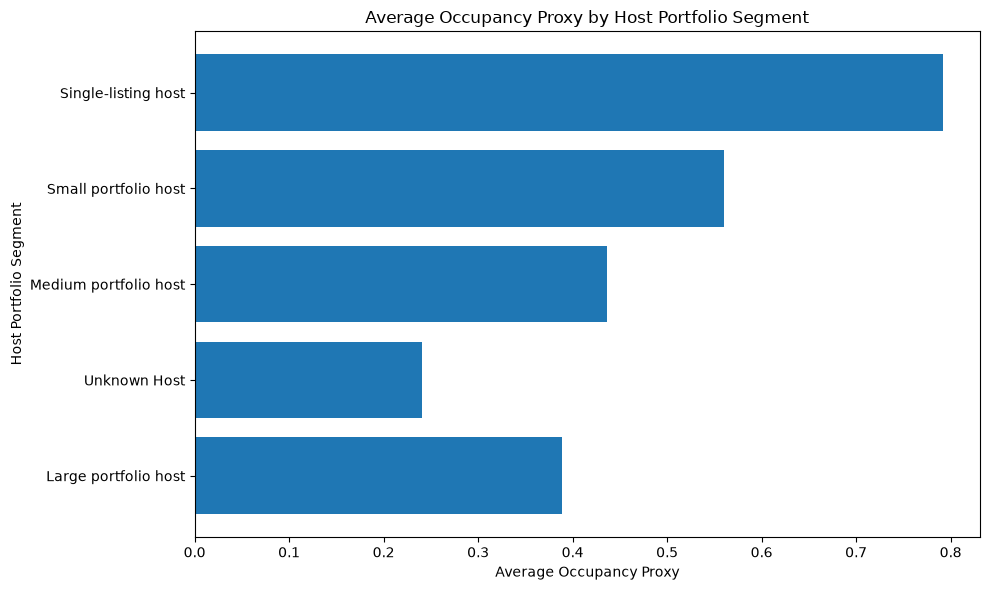

Saved figure to: ..\reports\figures\occupancy_proxy_by_host_portfolio_segment.png


In [27]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["avg_occupancy_proxy"]
)
plt.title("Average Occupancy Proxy by Host Portfolio Segment")
plt.xlabel("Average Occupancy Proxy")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Single-listing hosts show a high occupancy proxy compared with larger portfolio segments.  
This may indicate stronger demand, lower availability, or hosts blocking more calendar days.

Because occupancy proxy is based on unavailable days, it should be interpreted carefully and not treated as confirmed booking occupancy.

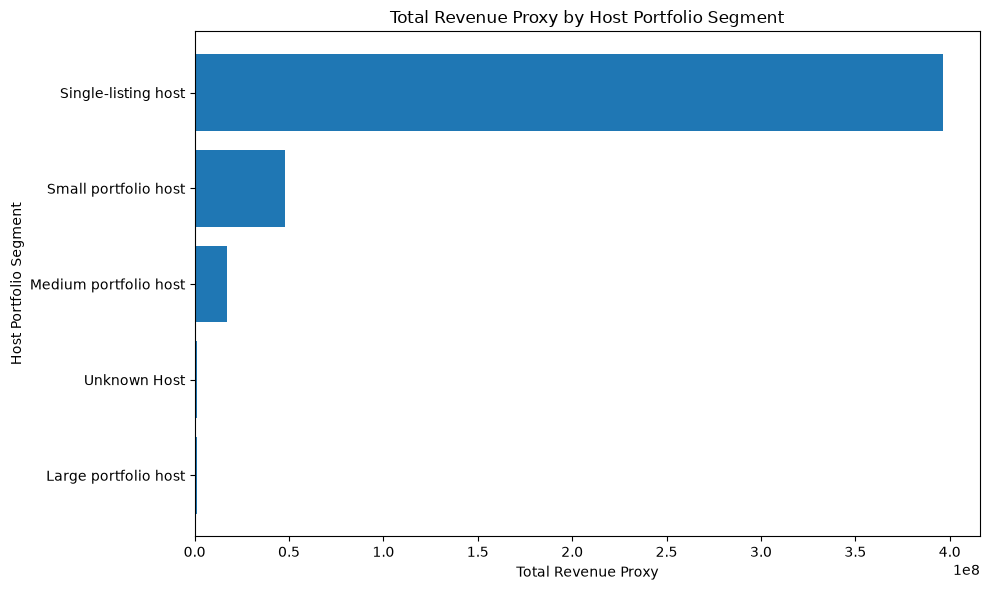

Saved figure to: ..\reports\figures\revenue_proxy_by_host_portfolio_segment.png


In [28]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["total_revenue_proxy"]
)
plt.title("Total Revenue Proxy by Host Portfolio Segment")
plt.xlabel("Total Revenue Proxy")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "revenue_proxy_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Single-listing hosts generate the largest total revenue proxy mainly because they represent the largest listing segment.

This does not mean every single-listing host earns more individually.  
For individual performance, average revenue proxy should be considered together with listing count, price availability, neighbourhood, and occupancy proxy.